# Visualizing `testhead_E.mat` — 64-electrode head mesh

**What's actually in your file** (verified by inspecting it directly):

| Variable | Shape | Meaning |
|---|---|---|
| `Geometry.node` | `(15066, 3)` | node coordinates in mm |
| `Geometry.cell` | `(66229, 4)` | tetrahedra, **1-based** MATLAB indices |
| `electrode_pot` | `(15066, 1)` | per-node electrode label: `-1` = scalp, `1..64` = electrode ID |

There is **no variable named `testhead_E`** — that's just the filename. The data lives inside a
struct called `Geometry`, which is why every `data["testhead_E"]` attempt raised `KeyError`.

Also note: **this file contains no E-field.** It's a volume conductor mesh plus an electrode
montage — simulation *input*, not output. The `_E` in the filename appears to mean *electrode*.
See the last section for what that means.

Run cells in order.

## 1. Setup

In [ ]:
%pip install scipy numpy matplotlib plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat

PATH = Path(r"C:\S.R\SCIBS\data\testhead_E.mat")

d = loadmat(PATH, struct_as_record=False, squeeze_me=False)
print("variables in file:", [k for k in d if not k.startswith("__")])

geom = d["Geometry"][0, 0]
node = np.asarray(geom.node, dtype=float)       # (15066, 3) mm
cell = np.asarray(geom.cell, dtype=int) - 1     # 1-based -> 0-based
elec = np.asarray(d["electrode_pot"]).ravel()   # (15066,) labels

print(f"\nnode  {node.shape}   cell  {cell.shape}   elec  {elec.shape}")
print(f"electrodes: {int((np.unique(elec) >= 1).sum())}")
print(f"scalp nodes (label -1): {int((elec == -1).sum())}")
for i, ax in enumerate("xyz"):
    print(f"  {ax}: {node[:, i].min():7.1f} .. {node[:, i].max():7.1f} mm")

variables in file: ['Geometry', 'electrode_pot']

node  (15066, 3)   cell  (66229, 4)   elec  (15066,)
electrodes: 64
scalp nodes (label -1): 9974
  x:   -73.4 ..    73.7 mm
  y:   -96.7 ..   105.4 mm
  z:   -54.6 ..    90.0 mm


## 2. Extract the outer surface

The mesh is *tetrahedral* (solid volume), so there's no ready-made surface to draw. Standard
trick: every internal face is shared by exactly two tets, while boundary faces belong to only
one. So collect all four faces of every tet and keep the ones appearing exactly once.

Takes under a second for this mesh; yields ~18k triangles.

In [ ]:
faces = np.vstack([cell[:, [0,1,2]], cell[:, [0,1,3]], cell[:, [0,2,3]], cell[:, [1,2,3]]])
uniq, counts = np.unique(np.sort(faces, axis=1), axis=0, return_counts=True)
surf = uniq[counts == 1]

print(f"surface triangles: {len(surf):,}  (from {len(faces):,} tet faces)")
print(f"surface nodes:     {len(np.unique(surf)):,}")

surface triangles: 18,360  (from 264,916 tet faces)
surface nodes:     9,017


## 3. Static render — matplotlib

Quick check that everything lines up. Two viewpoints, electrodes colored by ID.

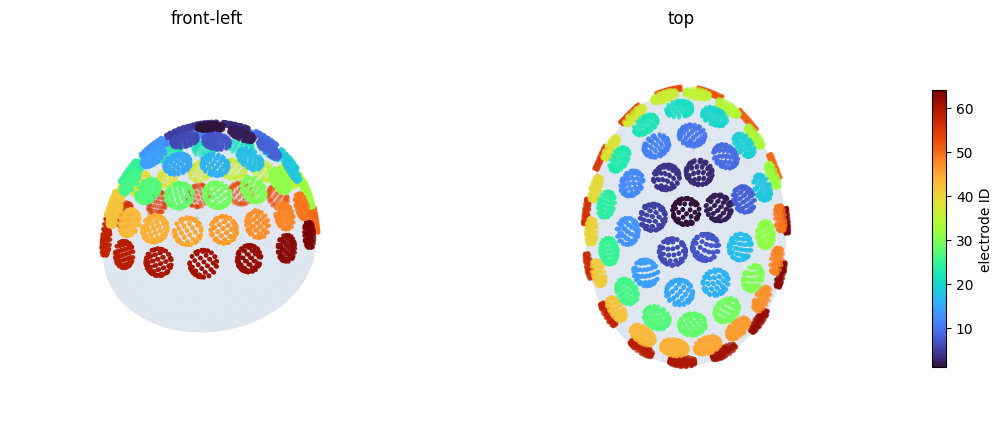

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

spans = [node[:, i].max() - node[:, i].min() for i in range(3)]
is_e = elec >= 1

fig = plt.figure(figsize=(14, 6))
for i, (elev, azim, title) in enumerate([(15, -70, "front-left"), (80, -90, "top")]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    ax.add_collection3d(Poly3DCollection(
        node[surf], alpha=0.22, facecolor="lightsteelblue", edgecolor="none"))
    p = ax.scatter(node[is_e, 0], node[is_e, 1], node[is_e, 2],
                   c=elec[is_e], cmap="turbo", s=5)
    for j, a in enumerate("xyz"):
        getattr(ax, f"set_{a}lim")(node[:, j].min(), node[:, j].max())
    ax.set_box_aspect(spans)
    ax.view_init(elev, azim)
    ax.set_title(title)
    ax.axis("off")
fig.colorbar(p, ax=fig.axes, shrink=0.6, label="electrode ID")
plt.show()

## 4. Interactive 3D — plotly

Rotate and zoom in the notebook. The scalp is a translucent `Mesh3d`; electrodes are
overlaid as points colored by ID. Hover an electrode to read its number.

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# translucent scalp surface
fig.add_trace(go.Mesh3d(
    x=node[:, 0], y=node[:, 1], z=node[:, 2],
    i=surf[:, 0], j=surf[:, 1], k=surf[:, 2],
    color="lightsteelblue", opacity=0.30,
    flatshading=False, name="scalp", hoverinfo="skip",
))

# electrodes
m = elec >= 1
fig.add_trace(go.Scatter3d(
    x=node[m, 0], y=node[m, 1], z=node[m, 2], mode="markers",
    marker=dict(size=2.5, color=elec[m], colorscale="Turbo",
                showscale=True, colorbar=dict(title="electrode")),
    text=[f"electrode {v}" for v in elec[m]],
    hovertemplate="%{text}<extra></extra>", name="electrodes",
))

fig.update_layout(
    title="64-electrode montage on head mesh",
    width=880, height=760, scene_aspectmode="data",
    scene=dict(xaxis_title="x (mm)", yaxis_title="y (mm)", zaxis_title="z (mm)"),
)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 5. Electrode positions table

Centroid of each electrode's nodes. Useful for identifying which is which — the one nearest
`(0, 0, z_max)` is typically Cz.

In [ ]:
import sys
print(sys.executable)
try:
    import nbformat; print("nbformat", nbformat.__version__)
except ImportError:
    print("nbformat NOT importable from this kernel")

c:\python\python.exe
nbformat 5.11.0


In [ ]:
ids = np.unique(elec[elec >= 1])
cent = np.array([node[elec == i].mean(axis=0) for i in ids])
counts = np.array([int((elec == i).sum()) for i in ids])

print(f"{'ID':>3}  {'nodes':>5}  {'x':>7} {'y':>7} {'z':>7}")
for i, c, n in zip(ids, cent, counts):
    print(f"{i:>3}  {n:>5}  {c[0]:7.1f} {c[1]:7.1f} {c[2]:7.1f}")

top = ids[np.argmax(cent[:, 2])]
print(f"\nhighest electrode (likely Cz): {top}")

## 6. Cut-away view — see inside the volume

Clip the tetrahedra by a plane to confirm the mesh really is solid rather than a shell.

In [ ]:
import plotly.graph_objects as go

y_cut = float(np.median(node[:, 1]))
tet_c = node[cell].mean(axis=1)                 # tet centroids
keep = cell[tet_c[:, 1] < y_cut]

f2 = np.vstack([keep[:, [0,1,2]], keep[:, [0,1,3]], keep[:, [0,2,3]], keep[:, [1,2,3]]])
u2, c2 = np.unique(np.sort(f2, axis=1), axis=0, return_counts=True)
cut = u2[c2 == 1]

go.Figure(go.Mesh3d(
    x=node[:, 0], y=node[:, 1], z=node[:, 2],
    i=cut[:, 0], j=cut[:, 1], k=cut[:, 2],
    intensity=node[:, 2], colorscale="Turbo", opacity=1.0,
)).update_layout(
    title=f"cut at y = {y_cut:.1f} mm  ({len(keep):,} tets)",
    width=820, height=720, scene_aspectmode="data",
).show()

---
## About the missing E-field

This file has geometry and an electrode montage, but **no field values**. Nothing here is
`(15066, 3)` field data or a `(nx, ny, nz)` volume — `electrode_pot` is an integer *label*
per node (`-1` or `1..64`), not a potential in volts.

So if you're trying to visualize an E-field, you need a second file. Either:

1. **The solver output** — the SCIBS run that takes this mesh plus boundary conditions and
   produces a potential or field per node. Look in the same folder for another `.mat` with a
   `(15066, 1)` float array (potential φ) or `(15066, 3)` / `(66229, 3)` (E-field vectors).
2. **You haven't run the simulation yet** — in which case this file is the input you'd feed it.

Once you have a per-node field array, add it to this notebook like so:

```python
E = loadmat("...")["E"]                       # (15066, 3) or (15066, 1)
mag = np.linalg.norm(E, axis=1) if E.ndim == 2 and E.shape[1] == 3 else E.ravel()

go.Figure(go.Mesh3d(
    x=node[:,0], y=node[:,1], z=node[:,2],
    i=surf[:,0], j=surf[:,1], k=surf[:,2],
    intensity=mag, colorscale="Turbo",
    cmin=0, cmax=float(np.percentile(mag, 99)),   # clip outliers
    colorbar=dict(title="|E| (V/m)"),
)).update_layout(scene_aspectmode="data", width=850, height=750).show()
```

`intensity` on the same `Mesh3d` gives you the field painted on the head surface, which is the
standard way these results are presented.

## Notes

- **`cell` is 1-based.** MATLAB indexes from 1, Python from 0. Cell 1 subtracts 1. Forget this
  and you get an off-by-one that silently corrupts the geometry, or an `IndexError` on the
  last node.
- **Use percentile clipping, not min/max,** for field color scales. Field magnitudes near
  electrode edges spike and will wash out everything else.